In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

print("Path to dataset files:", path)

100%|██████████| 12.3G/12.3G [01:00<00:00, 217MB/s] 

Extracting files...


Path to dataset files: /home/atchu2504/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1


In [4]:
#extracting data from zip file
import tarfile
import os

tar_file_path = '/home/atchu2504/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1/BraTS2021_Training_Data.tar'  # Replace with your file path
extract_dir = '/home/atchu2504/training/data'  # Output directory

os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(tar_file_path, 'r') as tar:
    tar.extractall(path=extract_dir)
    print("Extraction completed.")

# Verify dataset size after extraction
extracted_folders = [f for f in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, f))]
print(f"Total BraTS 2021 subjects extracted: {len(extracted_folders)}")

Extraction completed.
Total BraTS 2021 subjects extracted: 1251


In [ ]:
import os
import zipfile

zip_file_path = '/home/atchu2504/.synapseCache/768/124662768/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData.zip'
extract_dir = '/home/atchu2504/training/validation'

os.makedirs(extract_dir, exist_ok=True)

# Use zipfile instead of tarfile
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    print("Extraction completed.")

# Verify extraction
extracted_folders = [f for f in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, f))]
print(f"Total subjects extracted: {len(extracted_folders)}")

Extraction completed.
Total subjects extracted: 1


: 

Loading dataset...
Found 1251 valid samples in /home/atchu2504/training/data

Dataset Split Summary:
Total samples: 1251
Training samples: 1000 (79.9%)
Validation samples: 251 (20.1%)

Using device: cuda

Testing train_loader...


/opt/conda/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Train Batch - Image shape: torch.Size([4, 3, 256, 256])
Train Batch - Label shape: torch.Size([4, 3, 256, 256])


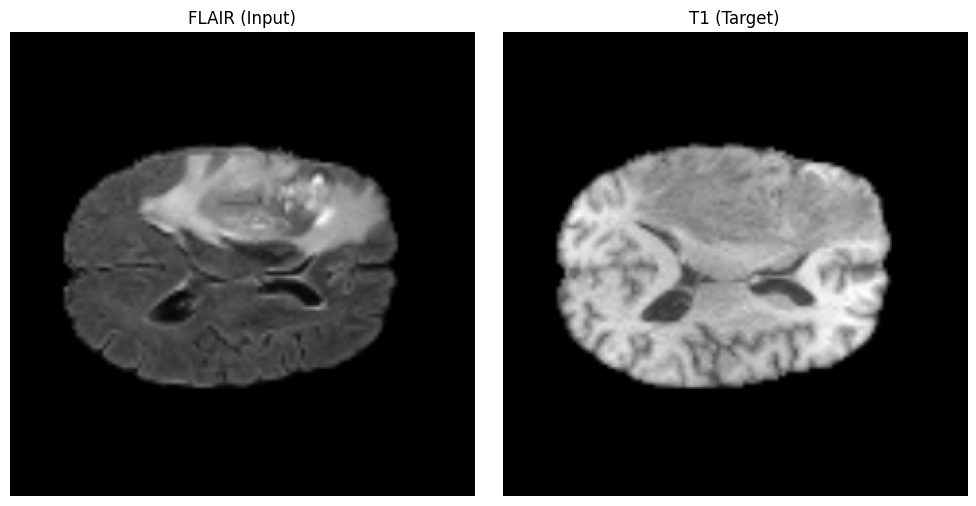


Testing val_loader...
Val Batch - Image shape: torch.Size([4, 3, 256, 256])
Val Batch - Label shape: torch.Size([4, 3, 256, 256])

✅ Data loaders created successfully!
✅ train_loader: 250 batches
✅ val_loader: 63 batches


In [2]:
# Improved Data Loading with Train/Validation Split
import os
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    Resized, ToTensord, MapTransform, RepeatChanneld
)
from monai.utils import set_determinism
import matplotlib.pyplot as plt

# --- Custom Transforms ---

class ExtractMidSlice(MapTransform):
    """
    Custom MONAI transform to extract the middle slice of a 3D volume
    to make it 2D for processing with standard 2D models.
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key]
            # Assuming channel first: [C, H, W, D]
            mid_idx = img.shape[-1] // 2
            d[key] = img[..., mid_idx] 
        return d

class NormalizeToOneRange(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            # Prevent division by zero
            denom = d[key].max() - d[key].min()
            if denom > 0:
                d[key] = (d[key] - d[key].min()) / denom
            else:
                d[key] = d[key] - d[key].min()
        return d

# --- Dataset Definition ---

class BraTSDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = self.get_valid_samples()

    def get_valid_samples(self):
        valid_samples = []
        if not os.path.exists(self.root_dir):
            print(f"Warning: Directory {self.root_dir} does not exist!")
            return []
        
        for folder in sorted(os.listdir(self.root_dir)):
            folder_path = os.path.join(self.root_dir, folder)
            if not os.path.isdir(folder_path): 
                continue
            
            flair_path = os.path.join(folder_path, f"{folder}_flair.nii.gz")
            t1_path = os.path.join(folder_path, f"{folder}_t1.nii.gz")
            
            if os.path.exists(flair_path) and os.path.exists(t1_path):
                valid_samples.append({"image": flair_path, "label": t1_path})
        
        print(f"Found {len(valid_samples)} valid samples in {self.root_dir}")
        return valid_samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample

# --- Pipeline Setup ---

def get_transforms():
    return Compose([
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(2.0, 2.0, 2.0), mode=("bilinear", "nearest")),
        # Extract 2D slice early to reduce memory overhead
        ExtractMidSlice(keys=["image", "label"]), 
        Resized(keys=["image", "label"], spatial_size=(256, 256), mode=("bilinear", "bilinear")),
        NormalizeToOneRange(keys=["image", "label"]),
        RepeatChanneld(keys=["image", "label"], repeats=3), # Make it 3-channel for torchvision models
        ToTensord(keys=["image", "label"]),
    ])

# --- Dataset and Split Creation ---

root_dir = "/home/atchu2504/training/data"
batch_size = 4  # Increased batch size as 2D is memory efficient
set_determinism(seed=0)

# Create full dataset
print("Loading dataset...")
full_dataset = BraTSDataset(root_dir=root_dir, transform=get_transforms())

# Create train/validation split (80/20)
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n{'='*60}")
print(f"Dataset Split Summary:")
print(f"{'='*60}")
print(f"Total samples: {dataset_size}")
print(f"Training samples: {train_size} ({train_size/dataset_size*100:.1f}%)")
print(f"Validation samples: {val_size} ({val_size/dataset_size*100:.1f}%)")
print(f"{'='*60}\n")

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0  # Set to 0 for Kaggle compatibility
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

# Test Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

print("Testing train_loader...")
for batch in train_loader:
    images, labels = batch['image'].to(device), batch['label'].to(device)
    print("Train Batch - Image shape:", images.shape)  # Should be (batch_size, 3, 256, 256)
    print("Train Batch - Label shape:", labels.shape)
    
    # Visualization check
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].set_title("FLAIR (Input)")
    axes[0].imshow(images[0, 0].cpu(), cmap='gray')
    axes[0].axis('off')
    
    axes[1].set_title("T1 (Target)")
    axes[1].imshow(labels[0, 0].cpu(), cmap='gray')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    break

print("\nTesting val_loader...")
for batch in val_loader:
    images, labels = batch['image'].to(device), batch['label'].to(device)
    print("Val Batch - Image shape:", images.shape)
    print("Val Batch - Label shape:", labels.shape)
    break

print("\n✅ Data loaders created successfully!")
print(f"✅ train_loader: {len(train_loader)} batches")
print(f"✅ val_loader: {len(val_loader)} batches")

In [3]:
# Additional imports for statistical analysis and GPU tracking
import time
import numpy as np
from scipy import stats
from collections import defaultdict
import json

# GPU Memory Tracking Class
class GPUMemoryTracker:
    def __init__(self):
        self.peak_memory = 0
        self.start_memory = 0
        
    def start(self):
        """Reset GPU memory statistics and record starting memory"""
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
            self.start_memory = torch.cuda.memory_allocated() / 1024**3  # GB
            print(f"Initial GPU Memory: {self.start_memory:.2f} GB")
    
    def update(self):
        """Update peak memory usage"""
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            self.peak_memory = torch.cuda.max_memory_allocated() / 1024**3  # GB
    
    def get_stats(self):
        """Get current memory statistics"""
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            current = torch.cuda.memory_allocated() / 1024**3
            peak = torch.cuda.max_memory_allocated() / 1024**3
            return {
                'current_gb': current,
                'peak_gb': peak,
                'allocated_gb': current - self.start_memory
            }
        return {'current_gb': 0, 'peak_gb': 0, 'allocated_gb': 0}
    
    def print_stats(self):
        """Print memory statistics"""
        stats = self.get_stats()
        print(f"\n{'='*50}")
        print(f"GPU Memory Statistics:")
        print(f"  Current Memory: {stats['current_gb']:.2f} GB")
        print(f"  Peak Memory: {stats['peak_gb']:.2f} GB")
        print(f"  Allocated (Training): {stats['allocated_gb']:.2f} GB")
        print(f"{'='*50}\n")

# Initialize GPU tracker
gpu_tracker = GPUMemoryTracker()

print("GPU Memory Tracker initialized!")

GPU Memory Tracker initialized!


Batch image shape: torch.Size([4, 3, 256, 256])


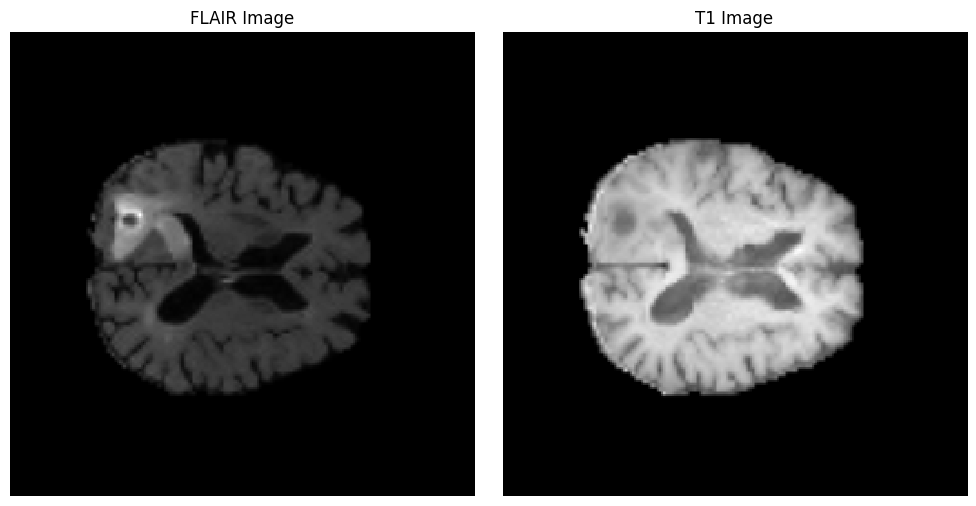

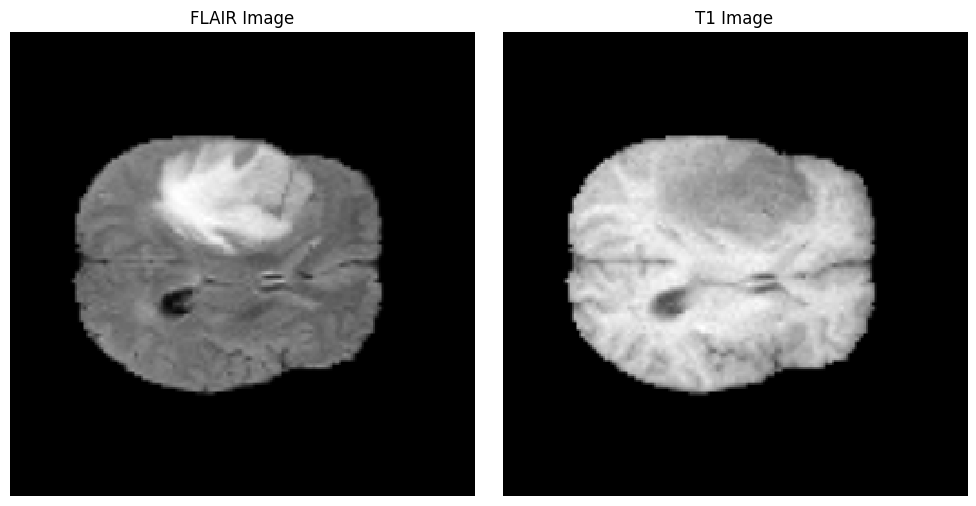

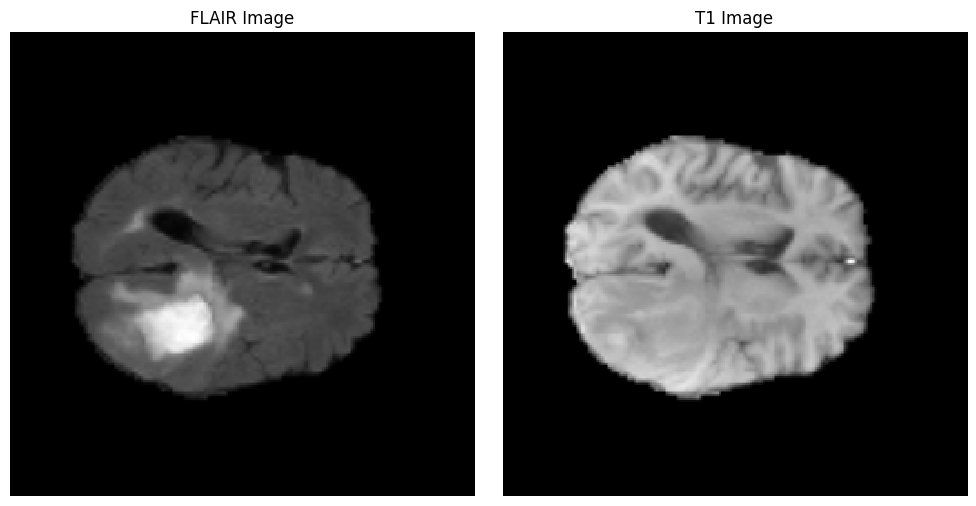

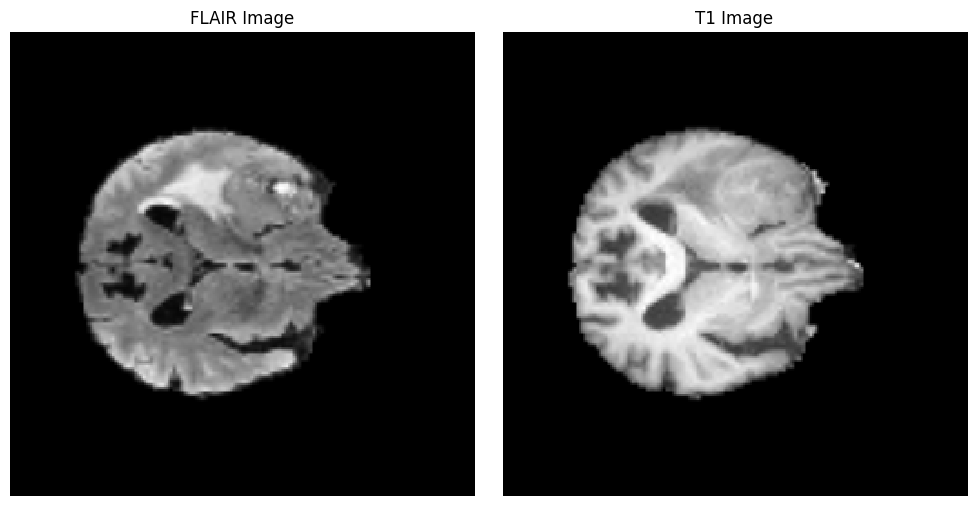

In [4]:
import matplotlib.pyplot as plt

# Function to display FLAIR and T1 images side by side
def display_flair_t1(flair_image, t1_image):
    flair_image = flair_image.squeeze(0).cpu()  
    t1_image = t1_image.squeeze(0).cpu() 

    # Plot FLAIR and T1 images side by side
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(flair_image, cmap='gray', interpolation='nearest') 
    plt.title('FLAIR Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(t1_image, cmap='gray', interpolation='nearest')
    plt.title('T1 Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def plot_mri_slices(batch, slice_number):
    """
    Plots the specified slice from the FLAIR and T1 MRI images in the given batch.

    Parameters:
        batch (dict): A dictionary containing 'image' and 'label' tensors.
        slice_number (int): The index of the slice to be plotted (0-based).
    """
    # Check the shape of the batch images
    print(f"Batch image shape: {batch['image'].shape}")

    num_dimensions = len(batch['image'].shape)
    
    if num_dimensions == 4: 
        # Extract FLAIR and T1 images from the batch
        flair_images = batch['image'][:, 0, :, :]  # Extract FLAIR slice
        t1_images = batch['label'][:, 0, :, :]   # Extract T1 slice
    elif num_dimensions == 5:  # shape is (batch_size, channels, depth, height, width)
        if slice_number < 0 or slice_number >= batch['image'].shape[4]:
            raise ValueError(f"Slice number must be between 0 and {batch['image'].shape[4] - 1}")
        flair_images = batch['image'][:, 0, :, :, slice_number]  # Extract FLAIR slice
        t1_images = batch['label'][:, 0, :, :, slice_number]   # Extract T1 slice
    else:
        raise ValueError("Unsupported tensor shape")

    num_samples = flair_images.shape[0]

    for i in range(num_samples):
        display_flair_t1(flair_images[i].unsqueeze(0), t1_images[i].unsqueeze(0))

for batch in train_loader:
    plot_mri_slices(batch, slice_number=5)  
    break  

In [10]:
#2D GAN
import torch
import torch.nn as nn

# --- Residual Block ---
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(dim)
        )

    def forward(self, x):
        return x + self.block(x)  # Skip connection


# --- ResNet Generator ---
class ResNetGenerator(nn.Module):
    def __init__(self, input_nc, output_nc, num_filters=64, num_res_blocks=9):
        """
        Args:
            input_nc (int): Number of input channels (e.g., 3 for RGB images).
            output_nc (int): Number of output channels (e.g., 3 for RGB images).
            num_filters (int): Nu mber of filters in the first convolution layer.
            num_res_blocks (int): Number of residual blocks in the generator.
        """
        super(ResNetGenerator, self).__init__()

        # Initial Convolution block
        model = [
            nn.Conv2d(input_nc, num_filters, kernel_size=7, stride=1, padding=3, bias=False),
            nn.InstanceNorm2d(num_filters),
            nn.ReLU(inplace=True)
        ]

        # Downsampling layers
        in_features = num_filters
        out_features = num_filters * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, kernel_size=3, stride=2, padding=1, bias=False),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features *= 2

        # Residual blocks
        for _ in range(num_res_blocks):
            model += [ResidualBlock(in_features)]

        # Upsampling layers
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_features, out_features, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features //= 2

        # Output layer
        model += [
            nn.Conv2d(num_filters, output_nc, kernel_size=7, stride=1, padding=3, bias=False),
            nn.Tanh()  
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

generator = ResNetGenerator(input_nc=3, output_nc=3, num_filters=64, num_res_blocks=9)
input_image = torch.randn(1, 3, 256, 256)  # A sample batch of images
output_image = generator(input_image)
print(output_image.shape)  # Should output torch.Size([1, 3, 256, 256])

torch.Size([1, 3, 256, 256])


In [11]:
import torch
import torch.nn as nn

# --- PatchGAN Discriminator ---
class PatchGANDiscriminator(nn.Module):
    def __init__(self, input_nc, num_filters=64, num_layers=3):
        """
        Args:
            input_nc (int): Number of input channels (e.g., 3 for RGB images).
            num_filters (int): Number of filters in the first convolution layer.
            num_layers (int): Number of layers to downsample the input image.
        """
        super(PatchGANDiscriminator, self).__init__()

        # Initial layer: No normalization for the first layer
        model = [
            nn.Conv2d(input_nc, num_filters, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        current_filters = num_filters
        for n in range(1, num_layers):
            next_filters = min(current_filters * 2, 512)
            model += [
                nn.Conv2d(current_filters, next_filters, kernel_size=4, stride=2, padding=1, bias=False),
                nn.InstanceNorm2d(next_filters),
                nn.LeakyReLU(0.2, inplace=True)
            ]
            current_filters = next_filters

        # Final convolution layer to produce a single-channel output
        model += [
            nn.Conv2d(current_filters, 1, kernel_size=4, stride=1, padding=1)
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


discriminator = PatchGANDiscriminator(input_nc=3, num_filters=64, num_layers=3)
input_image = torch.randn(1, 3, 256, 256)  # A sample batch of images
output = discriminator(input_image)
print(output.shape)  # Should output torch.Size([1, 1, 31, 31])

torch.Size([1, 1, 31, 31])


Error loading checkpoint: [Errno 2] No such file or directory: ''


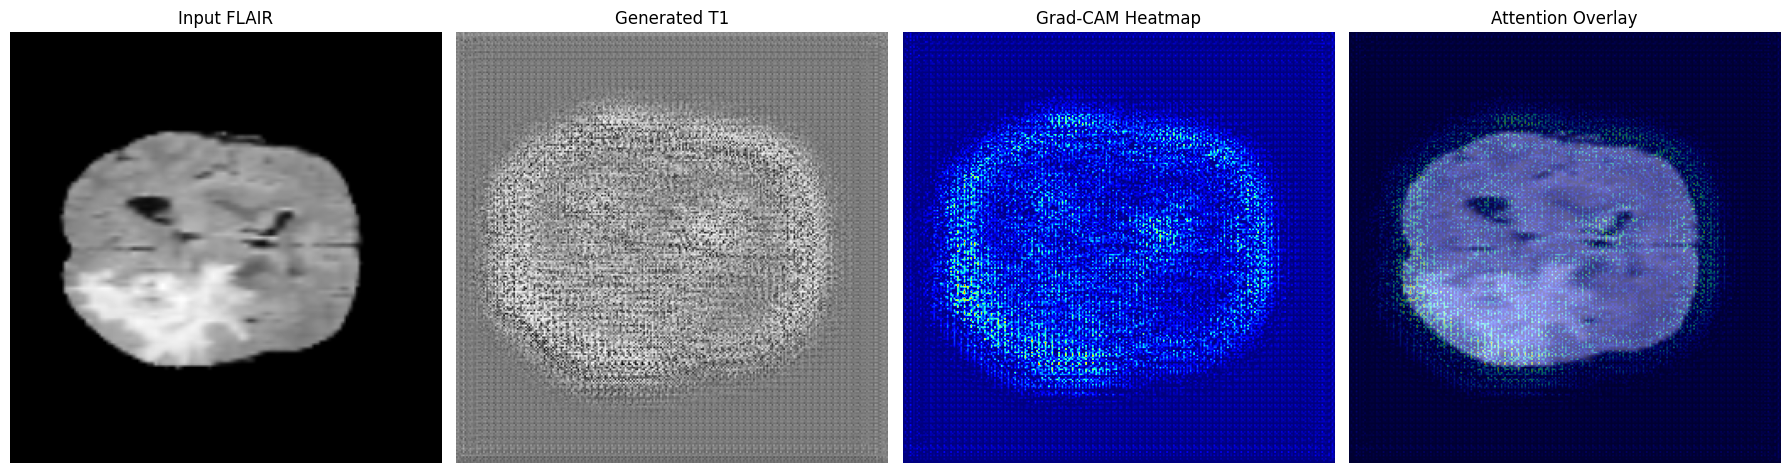

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# --- 1. GradCAM Class Definition ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        # Hooks to capture forward activations and backward gradients
        self.hook_activation = target_layer.register_forward_hook(self.save_activation)
        self.hook_gradient = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        # Capture the gradients flowing back to the target layer
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, output):
        self.model.zero_grad()
        
        # For a Generator, we backprop from the mean intensity of the output image
        # This shows what parts of the input contributed most to the generated pixels
        loss = output.mean()
        loss.backward(retain_graph=True)

        # Global Average Pooling of gradients across spatial dimensions
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Create heatmap via weighted sum of activations
        heatmap = torch.sum(weights * self.activations, dim=1, keepdim=True)

        # Process heatmap: ReLU to remove negative influence, then normalize
        heatmap = F.relu(heatmap)
        
        # Batch-wise normalization
        for i in range(heatmap.size(0)):
            m = heatmap[i].max()
            if m > 0:
                heatmap[i] /= m

        return heatmap

    def remove_hooks(self):
        self.hook_activation.remove()
        self.hook_gradient.remove()

# --- 2. Model Initialization & Checkpoint Loading ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-initialize the generator
generator_flair_to_t1 = ResNetGenerator(input_nc=3, output_nc=3, num_filters=64, num_res_blocks=9).to(device)

checkpoint_path = ''

try:
    # Use weights_only=False to support legacy checkpoint serialization
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    if isinstance(checkpoint, dict) and 'generator_flair_to_t1_state_dict' in checkpoint:
        state_dict = checkpoint['generator_flair_to_t1_state_dict']
    else:
        state_dict = checkpoint
        
    generator_flair_to_t1.load_state_dict(state_dict)
    print("Checkpoint loaded successfully.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")

# --- 3. Data Processing & Grad-CAM Generation ---
generator_flair_to_t1.eval()

# Get one batch from the loader
try:
    batch = next(iter(train_loader))
    real_flair = batch['image'].to(device)
    real_flair.requires_grad_() # Enable gradient tracking on input

    # Target the last convolutional layer (adjust index if your model differs)
    target_layer = generator_flair_to_t1.model[24]
    grad_cam = GradCAM(generator_flair_to_t1, target_layer)

    # Forward pass
    generated_t1 = generator_flair_to_t1(real_flair)

    # Generate the batch of heatmaps
    heatmap = grad_cam.generate_heatmap(generated_t1)
    
    # --- 4. Visualization (Fixing the Batch Shape Issue) ---
    
    # Select the FIRST sample in the batch for visualization
    # Shape becomes (256, 256)
    idx = 0 
    input_slice = real_flair[idx, 0].detach().cpu().numpy()  # Channel 0 of FLAIR
    heatmap_slice = heatmap[idx, 0].detach().cpu().numpy()  # Heatmap for sample 0
    generated_slice = generated_t1[idx, 0].detach().cpu().numpy() # Generated T1

    plt.figure(figsize=(18, 5))

    # Plot 1: Input FLAIR
    plt.subplot(1, 4, 1)
    plt.imshow(input_slice, cmap='gray')
    plt.title("Input FLAIR")
    plt.axis('off')

    # Plot 2: Generated T1
    plt.subplot(1, 4, 2)
    plt.imshow(generated_slice, cmap='gray')
    plt.title("Generated T1")
    plt.axis('off')

    # Plot 3: Heatmap Only
    plt.subplot(1, 4, 3)
    plt.imshow(heatmap_slice, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')

    # Plot 4: Overlay (Heatmap on FLAIR)
    plt.subplot(1, 4, 4)
    plt.imshow(input_slice, cmap='gray')
    plt.imshow(heatmap_slice, cmap='jet', alpha=0.4) # 40% transparency overlay
    plt.title("Attention Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Always remove hooks to prevent memory leaks and unexpected behavior in future runs
    grad_cam.remove_hooks()

except StopIteration:
    print("The train_loader is empty.")
except Exception as e:
    print(f"An error occurred during visualization: {e}")

In [9]:
#training loop with GPU and time tracking
# Check for CUDA
import torch
import torch.nn as nn
import torch.optim as optim  # Fixed: Missing import
import time                  # Fixed: Missing import
from tqdm import tqdm
from torchvision import models
from skimage.metrics import structural_similarity as ssim
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MultiScaleDiscriminator(nn.Module):
    def __init__(self, input_nc, num_filters=64, num_layers=3):
        super(MultiScaleDiscriminator, self).__init__()
        self.discriminators = nn.ModuleList()
        self.discriminators.append(PatchGANDiscriminator(input_nc, num_filters, num_layers))

    def forward(self, x):
        return [disc(x) for disc in self.discriminators]

# Initialize models
generator_flair_to_t1 = ResNetGenerator(input_nc=3, output_nc=3, num_filters=64, num_res_blocks=9).to(device)
generator_t1_to_flair = ResNetGenerator(input_nc=3, output_nc=3, num_filters=64, num_res_blocks=9).to(device)
discriminator_flair = MultiScaleDiscriminator(input_nc=3, num_filters=64, num_layers=3).to(device)
discriminator_t1 = MultiScaleDiscriminator(input_nc=3, num_filters=64, num_layers=3).to(device)

# Initialize optimizers
optimizer_G = optim.Adam(
    list(generator_flair_to_t1.parameters()) + list(generator_t1_to_flair.parameters()),
    lr=2e-4,
    betas=(0.5, 0.999)
)

optimizer_D_flair = optim.Adam(discriminator_flair.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D_t1 = optim.Adam(discriminator_t1.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Define loss functions
criterion_GAN = nn.MSELoss()  # Adversarial loss
criterion_L1 = nn.L1Loss()     # L1 reconstruction loss

# Pre-trained VGG model for perceptual loss
vgg = models.vgg19(pretrained=True).features.to(device).eval()
for param in vgg.parameters():
    param.requires_grad = False

def perceptual_loss(fake, real):
    fake_features = vgg(fake)
    real_features = vgg(real)
    return nn.L1Loss()(fake_features, real_features)

# Function to calculate SSIM loss
def ssim_loss(fake, real):
    # Detach tensors to prevent gradient tracking and convert to numpy arrays
    fake_np = fake.detach().permute(0, 2, 3, 1).cpu().numpy()
    real_np = real.detach().permute(0, 2, 3, 1).cpu().numpy()
    
    ssim_scores = [
        ssim(fake_np[i], real_np[i], win_size=3, channel_axis=2, data_range=1.0)  # Add data_range parameter
        for i in range(fake_np.shape[0])
    ]
    ssim_avg = torch.tensor(ssim_scores).mean().to(device)
    return 1 - ssim_avg 



# Define the path to the saved checkpoint
checkpoint_path = '/kaggle/input/epoch-20/pytorch/default/1/checkpoint_final (16).pth'
# Load the checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load models' state dictionaries
generator_flair_to_t1.load_state_dict(checkpoint['generator_flair_to_t1_state_dict'])
generator_t1_to_flair.load_state_dict(checkpoint['generator_t1_to_flair_state_dict'])
discriminator_flair.load_state_dict(checkpoint['discriminator_flair_state_dict'])
discriminator_t1.load_state_dict(checkpoint['discriminator_t1_state_dict'])

# Load optimizers' state dictionaries
optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
optimizer_D_flair.load_state_dict(checkpoint['optimizer_D_flair_state_dict'])
optimizer_D_t1.load_state_dict(checkpoint['optimizer_D_t1_state_dict'])

# Load the last completed epoch if you want to continue training
start_epoch = checkpoint['epoch']

print(f"Checkpoint loaded. Resuming from epoch {start_epoch + 1}.")

# START GPU MEMORY AND TIME TRACKING
gpu_tracker.start()
training_start_time = time.time()

num_epochs = 0

# Lists to store losses
G_losses = []
D_flair_losses = []
D_t1_losses = []

# Training loop
for epoch in range(num_epochs):
    epoch_start_time = time.time()
    
    generator_flair_to_t1.train()
    generator_t1_to_flair.train()
    discriminator_flair.train()
    discriminator_t1.train()

    # Lists to store epoch losses
    epoch_G_loss = 0.0
    epoch_D_flair_loss = 0.0
    epoch_D_t1_loss = 0.0

    # Iterate through the train_loader
    for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', total=len(train_loader)):
        # Get images from the dataloader
        real_flair = batch['image'].to(device)  # Flair images
        real_t1 = batch['label'].to(device)  # T1 images

        # ---- Train Generators ----
        optimizer_G.zero_grad()

        # Generate fake images
        fake_t1 = generator_flair_to_t1(real_flair)  # Flair to T1
        fake_flair = generator_t1_to_flair(real_t1)  # T1 to Flair

        # Calculate L1 and SSIM losses
        loss_L1_flair_to_t1 = criterion_L1(fake_t1, real_t1)
        loss_L1_t1_to_flair = criterion_L1(fake_flair, real_flair)
        
        loss_SSIM_flair_to_t1 = ssim_loss(fake_t1, real_t1)
        loss_SSIM_t1_to_flair = ssim_loss(fake_flair, real_flair)

        # Calculate GAN loss
        loss_GAN_flair_to_t1 = sum(criterion_GAN(output, torch.ones_like(output).to(device)) for output in discriminator_t1(fake_t1)) / len(discriminator_t1(fake_t1))
        loss_GAN_t1_to_flair = sum(criterion_GAN(output, torch.ones_like(output).to(device)) for output in discriminator_flair(fake_flair)) / len(discriminator_flair(fake_flair))

        # Total generator loss (Pix2Pix style)
        total_G_loss = (
            loss_GAN_flair_to_t1 +
            loss_GAN_t1_to_flair +
            100 * (loss_L1_flair_to_t1 + loss_L1_t1_to_flair) +  # Increased weight for L1 loss
            10 * (loss_SSIM_flair_to_t1 + loss_SSIM_t1_to_flair)  # SSIM loss with chosen weight
        )

        total_G_loss.backward()
        optimizer_G.step()

        # ---- Train Discriminators ----
        optimizer_D_flair.zero_grad()
        optimizer_D_t1.zero_grad()

        # Calculate adversarial loss for Discriminator Flair
        real_flair_outputs = discriminator_flair(real_flair)
        fake_flair_outputs = discriminator_flair(fake_flair.detach())
        
        loss_D_flair_real = sum(criterion_GAN(output, torch.ones_like(output).to(device)) for output in real_flair_outputs) / len(real_flair_outputs)
        loss_D_flair_fake = sum(criterion_GAN(output, torch.zeros_like(output).to(device)) for output in fake_flair_outputs) / len(fake_flair_outputs)
        loss_D_flair = (loss_D_flair_real + loss_D_flair_fake) * 0.5
        loss_D_flair.backward()
        optimizer_D_flair.step()

        # Calculate adversarial loss for Discriminator T1
        real_t1_outputs = discriminator_t1(real_t1)
        fake_t1_outputs = discriminator_t1(fake_t1.detach())
        
        loss_D_t1_real = sum(criterion_GAN(output, torch.ones_like(output).to(device)) for output in real_t1_outputs) / len(real_t1_outputs)
        loss_D_t1_fake = sum(criterion_GAN(output, torch.zeros_like(output).to(device)) for output in fake_t1_outputs) / len(fake_t1_outputs)
        loss_D_t1 = (loss_D_t1_real + loss_D_t1_fake) * 0.5
        loss_D_t1.backward()
        optimizer_D_t1.step()

        # Accumulate losses for averaging later
        epoch_G_loss += total_G_loss.item()
        epoch_D_flair_loss += loss_D_flair.item()
        epoch_D_t1_loss += loss_D_t1.item()
        
        # Update GPU memory tracking
        gpu_tracker.update()

    # Average the losses for the epoch
    avg_G_loss = epoch_G_loss / len(train_loader)
    avg_D_flair_loss = epoch_D_flair_loss / len(train_loader)
    avg_D_t1_loss = epoch_D_t1_loss / len(train_loader)
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start_time

    # Print the average losses for the epoch with timing
    print(f'Epoch [{epoch + 1}/{num_epochs}] - Time: {epoch_time/60:.2f} min, '
          f'Generator Loss: {avg_G_loss:.4f}, '
          f'Discriminator Flair Loss: {avg_D_flair_loss:.4f}, '
          f'Discriminator T1 Loss: {avg_D_t1_loss:.4f}')

    # Save checkpoint after each epoch
    torch.save({
        'epoch': epoch,
        'generator_flair_to_t1_state_dict': generator_flair_to_t1.state_dict(),
        'generator_t1_to_flair_state_dict': generator_t1_to_flair.state_dict(),
        'discriminator_flair_state_dict': discriminator_flair.state_dict(),
        'discriminator_t1_state_dict': discriminator_t1.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_flair_state_dict': optimizer_D_flair.state_dict(),
        'optimizer_D_t1_state_dict': optimizer_D_t1.state_dict()
    }, f'checkpoint_epoch_{epoch + 1}.pth')

# Calculate total training time
total_training_time = time.time() - training_start_time

print(f"\n{'='*60}")
print(f"Training completed!")
print(f"Total Training Time: {total_training_time/3600:.2f} hours ({total_training_time/60:.2f} minutes)")
print(f"{'='*60}\n")

# Print GPU memory statistics
gpu_tracker.print_stats()

NameError: name 'ResNetGenerator' is not defined

In [10]:
import synapseclient
from dotenv import load_dotenv
load_dotenv()
token=os.environ.get('SYNAPSE_PERSONAL_TOKEN')
syn = synapseclient.login(authToken=token)

Welcome, atchusg!



In [11]:
dl_list_file_entities = syn.get_download_list()

/download/list/manifest/async:   0%|          | 0.00/1.00 [00:00<?, ?it/s]

[syn51514110]: Downloaded to /home/atchu2504/.synapseCache/768/124662768/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData.zip


In [12]:
!cd /home/atchu2504/.synapseCache/768/124662768 && ls

ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData.zip


Loaded — epoch 83,  best SSIM 0.8864
PersistentDataset cache: /home/atchu2504/training/cache
  First run: builds cache (slow). Subsequent epochs: instant reads.
Split: 1001 train / 250 val (total 1251)


/opt/conda/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


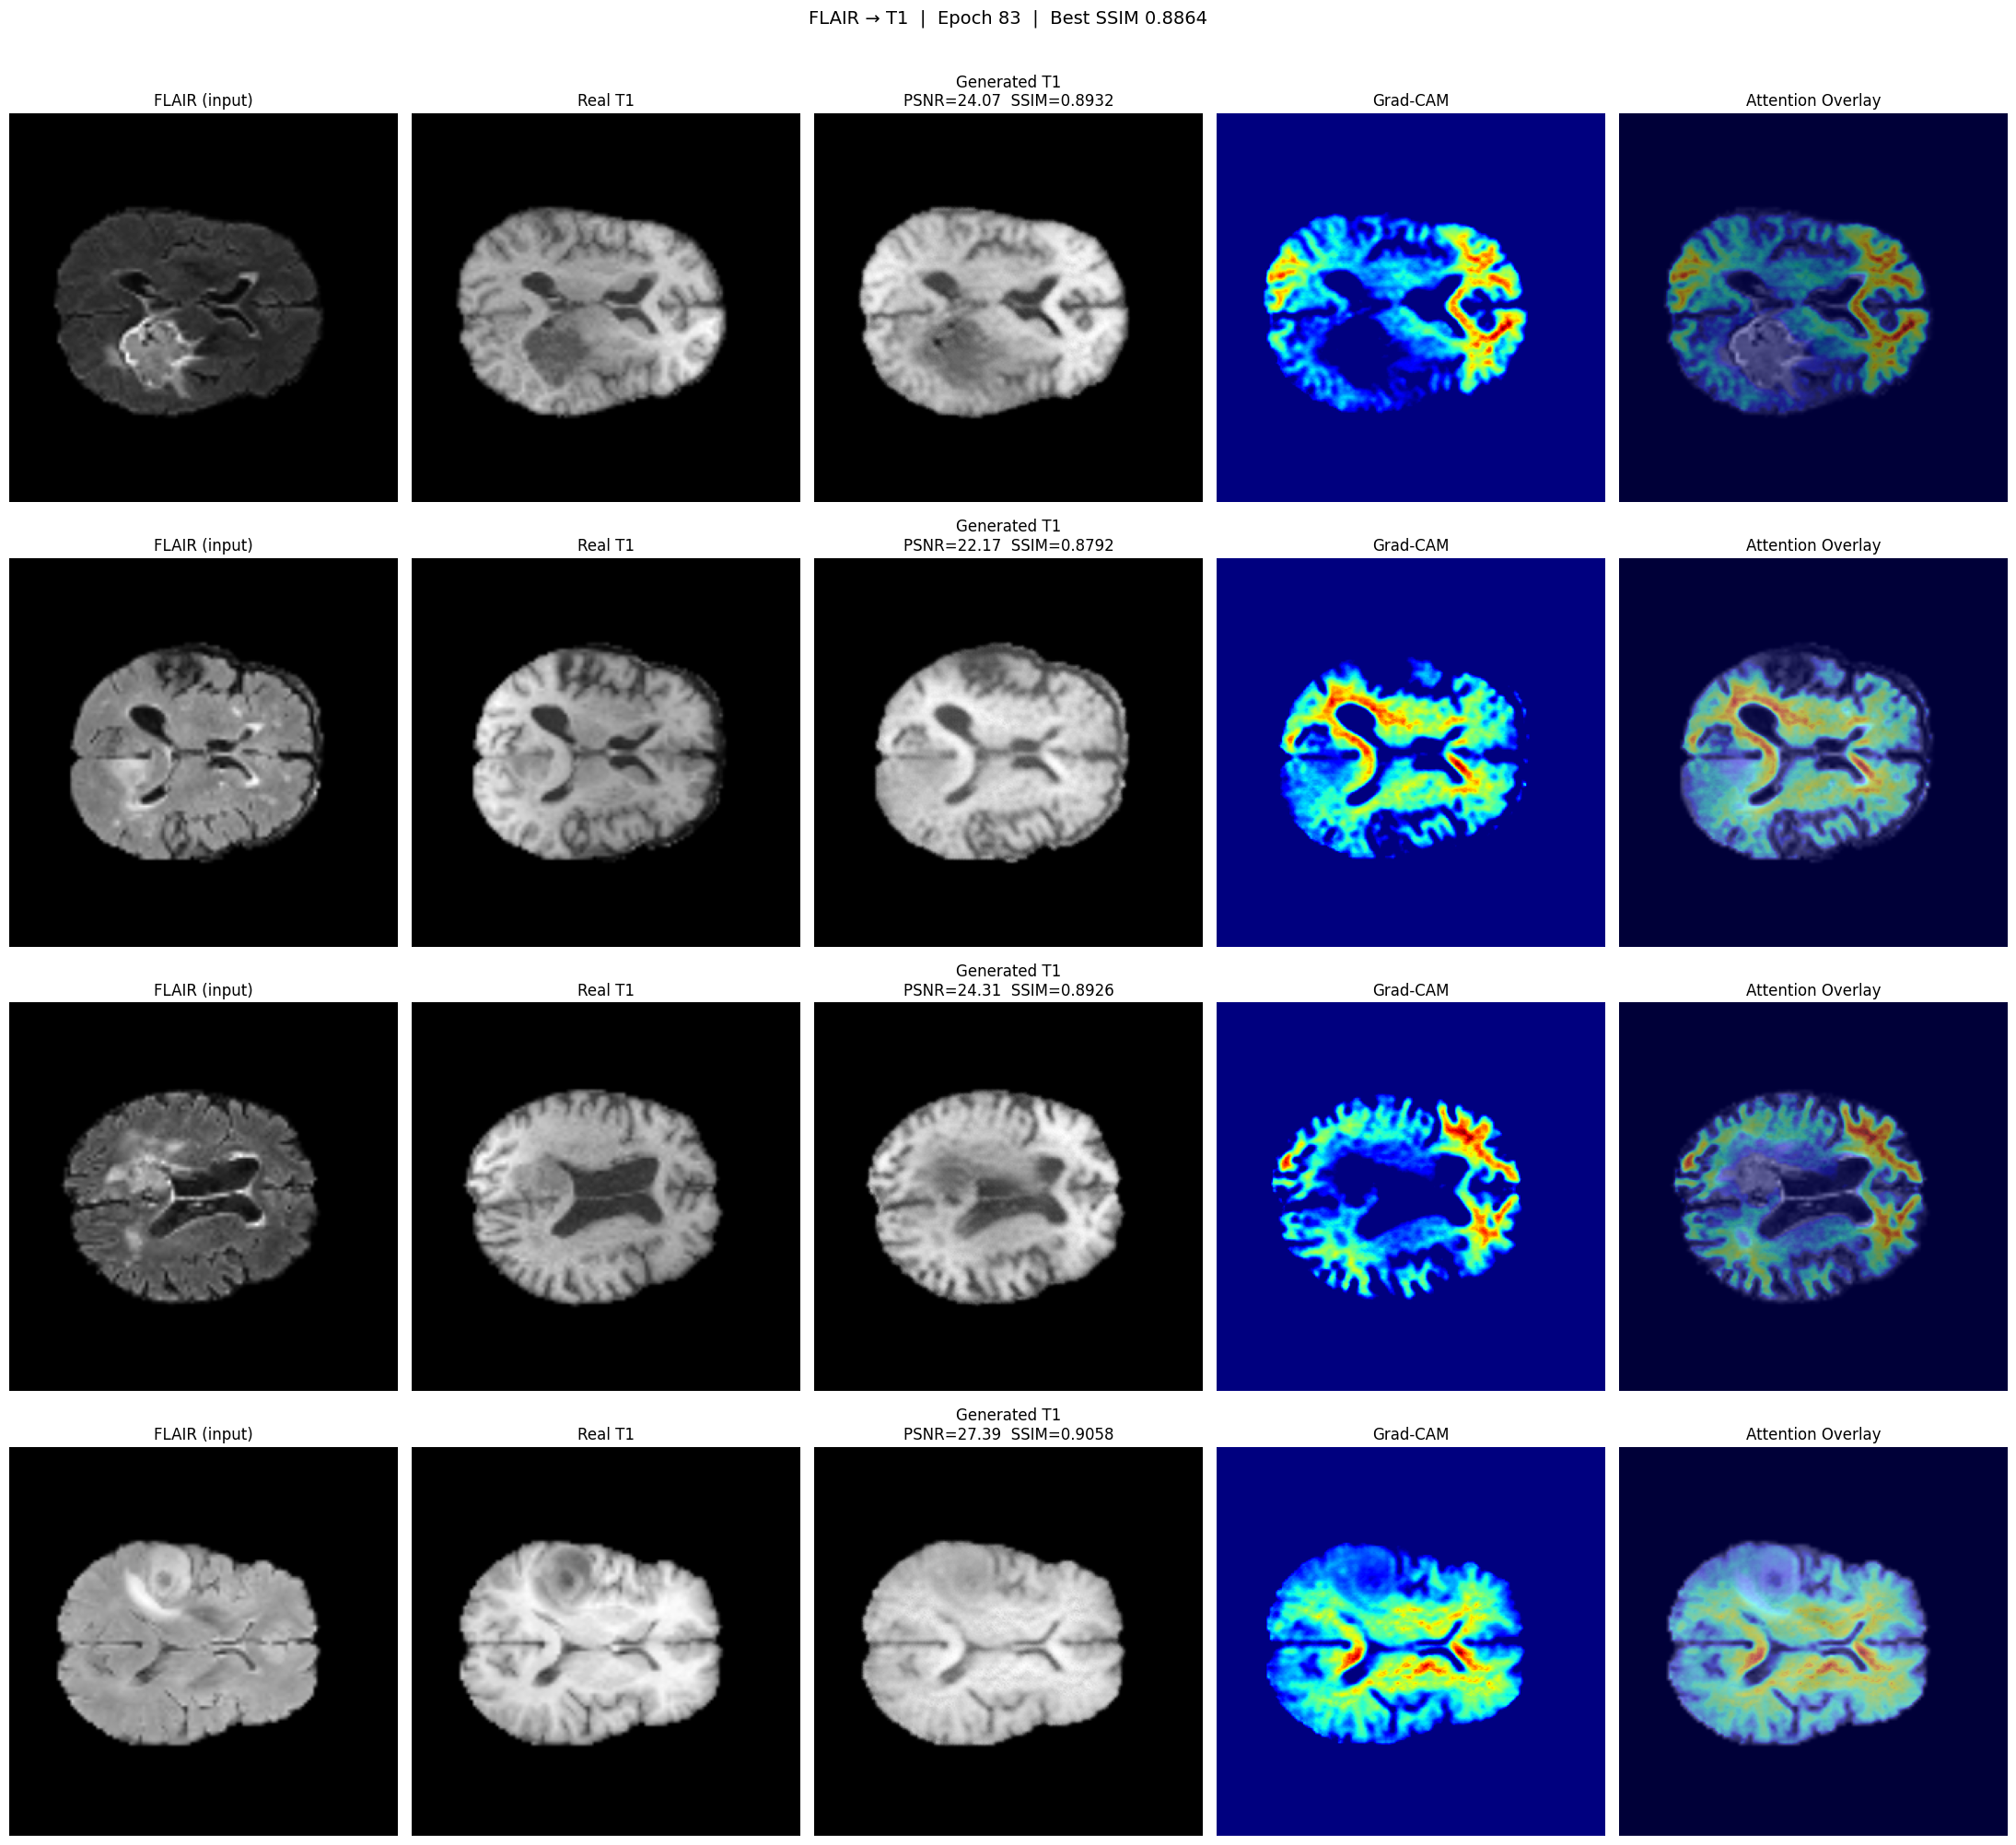

Saved → /home/atchu2504/training/outputs/resnet9/gradcam_test.png


In [1]:
import sys, os
sys.path.insert(0, '/home/atchu2504/training')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

from models import ResNet9Generator
from dataset import create_dataloaders

# ── config ───────────────────────────────────────────────────────────────────
CHECKPOINT = '/home/atchu2504/training/outputs/resnet9_v5/resnet9/checkpoints/best_model.pth'
DATA_DIR   = '/home/atchu2504/training/data'
CACHE_DIR  = '/home/atchu2504/training/cache'
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── GradCAM ──────────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x)
        out.mean().backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        for i in range(cam.size(0)):
            m = cam[i].max()
            if m > 0:
                cam[i] /= m
        return cam, out

# ── load model ────────────────────────────────────────────────────────────────
gen  = ResNet9Generator(in_channels=3, out_channels=3).to(device)
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)

# torch.compile saves weights with '_orig_mod.' prefix — strip it
state_dict = ckpt['gen']
if any(k.startswith('_orig_mod.') for k in state_dict.keys()):
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}

gen.load_state_dict(state_dict)
gen.eval()
print(f"Loaded — epoch {ckpt['epoch']},  best SSIM {ckpt['best_ssim']:.4f}")

# target = last Conv2d in ResNet9Generator (output 7x7 conv, index 26)
target_layer = gen.model[26]
grad_cam = GradCAM(gen, target_layer)

# ── load validation batch ─────────────────────────────────────────────────────
_, val_loader, _, _ = create_dataloaders(
    DATA_DIR, batch_size=4, seed=42, num_workers=0, cache_dir=CACHE_DIR)
batch   = next(iter(val_loader))
flair   = batch['image'].to(device)
t1_real = batch['label'].to(device)
flair.requires_grad_(True)

# ── run GradCAM ───────────────────────────────────────────────────────────────
cam, t1_fake = grad_cam(flair)

def to01(t):
    return ((t.detach() + 1) / 2).clamp(0, 1)

flair_01 = to01(flair)
fake_01  = to01(t1_fake)
real_01  = to01(t1_real)

# ── visualise ─────────────────────────────────────────────────────────────────
n = min(4, flair.size(0))
fig, axes = plt.subplots(n, 5, figsize=(22, 5 * n))

for idx in range(n):
    f = flair_01[idx, 0].detach().cpu().numpy()
    r = real_01 [idx, 0].detach().cpu().numpy()
    g = fake_01 [idx, 0].detach().cpu().numpy()
    h = cam     [idx, 0].detach().cpu().numpy()

    psnr = psnr_fn(r, g, data_range=1.0)
    sval = ssim_fn(r, g, data_range=1.0)

    axes[idx, 0].imshow(f, cmap='gray');  axes[idx, 0].set_title('FLAIR (input)')
    axes[idx, 1].imshow(r, cmap='gray');  axes[idx, 1].set_title('Real T1')
    axes[idx, 2].imshow(g, cmap='gray');  axes[idx, 2].set_title(f'Generated T1\nPSNR={psnr:.2f}  SSIM={sval:.4f}')
    axes[idx, 3].imshow(h, cmap='jet');   axes[idx, 3].set_title('Grad-CAM')
    axes[idx, 4].imshow(f, cmap='gray')
    axes[idx, 4].imshow(h, cmap='jet', alpha=0.45)
    axes[idx, 4].set_title('Attention Overlay')

    for ax in axes[idx]:
        ax.axis('off')

plt.suptitle(
    f"FLAIR → T1  |  Epoch {ckpt['epoch']}  |  Best SSIM {ckpt['best_ssim']:.4f}",
    fontsize=14, y=1.01)
plt.tight_layout()

out_path = '/home/atchu2504/training/outputs/resnet9/gradcam_test.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")
